# Customer Churn & Retention Intelligence

## Business Objective
This project identifies customers at risk of churn, explains the strongest churn signals,
analyzes time-to-churn, and quantifies monthly revenue exposure to support retention decisions.

### Key Business Questions
1. Which customers are most likely to churn?
2. What factors are associated with churn?
3. When are customers most vulnerable to churn?
4. Which customers should be prioritized based on risk and revenue exposure?

### Project Workflow
Data Validation → EDA → KPIs → Statistical Inference → Survival Analysis → Predictive Modeling → Risk Scoring → Revenue-at-Risk → Recommendations

> Power BI is used separately as the final presentation layer.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
customers = pd.read_csv("customers.csv")
subscription = pd.read_csv("subscription_monthly.csv")

In [9]:
customers.shape
customers.head()
customers.info()
customers.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               6000 non-null   object 
 1   signup_date               6000 non-null   object 
 2   plan_tier                 6000 non-null   object 
 3   monthly_price             6000 non-null   int64  
 4   contract_type             6000 non-null   object 
 5   payment_method            6000 non-null   object 
 6   country                   6000 non-null   object 
 7   industry                  6000 non-null   object 
 8   company_size_employees    6000 non-null   int64  
 9   monthly_active_users_pct  6000 non-null   float64
 10  feature_adoption_count    6000 non-null   int64  
 11  support_tickets_90d       6000 non-null   int64  
 12  avg_csat_score            6000 non-null   float64
 13  failed_payments_90d       6000 non-null   int64  
 14  last_log

,monthly_price,company_size_employees,monthly_active_users_pct,feature_adoption_count,support_tickets_90d,avg_csat_score,failed_payments_90d,last_login_days_ago,churned,tenure_months,lifetime_revenue
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,81.266667,30.222333,0.546582,4.020333,1.411500,3.935735,0.580833,11.342167,0.218000,19.324167,1580.745833
std,63.215464,69.693272,0.215935,2.013603,1.188586,0.804372,0.742894,12.180920,0.412922,12.484246,1785.274798
min,29.000000,1.000000,0.020000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,29.000000
25%,29.000000,7.000000,0.396000,3.000000,1.000000,3.400000,0.000000,3.000000,0.000000,8.000000,406.000000
50%,79.000000,16.000000,0.548000,4.000000,1.000000,3.990000,0.000000,8.000000,0.000000,17.000000,928.000000
75%,79.000000,34.000000,0.692000,5.000000,2.000000,4.600000,1.000000,16.000000,0.000000,29.000000,2133.000000
max,199.000000,4056.000000,1.000000,13.000000,8.000000,5.000000,2.000000,125.000000,1.000000,44.000000,8756.000000


In [10]:
subscription.shape
subscription.head()
subscription.info()
subscription.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115945 entries, 0 to 115944
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   customer_id   115945 non-null  object
 1   month         115945 non-null  object
 2   tenure_month  115945 non-null  int64 
 3   is_active     115945 non-null  int64 
 4   mrr           115945 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 4.4+ MB


,tenure_month,is_active,mrr
count,115945.000000,115945.0,115945.000000
mean,14.194092,1.0,81.801501
std,10.211438,0.0,63.184526
min,1.000000,1.0,29.000000
25%,6.000000,1.0,29.000000
50%,12.000000,1.0,79.000000
75%,21.000000,1.0,79.000000
max,44.000000,1.0,199.000000


## 1. Data Quality & Initial Validation


In [11]:
customers.duplicated().sum()

0

In [12]:
customers.isnull().sum()

customer_id                    0
signup_date                    0
plan_tier                      0
monthly_price                  0
contract_type                  0
payment_method                 0
country                        0
industry                       0
company_size_employees         0
monthly_active_users_pct       0
feature_adoption_count         0
support_tickets_90d            0
avg_csat_score                 0
failed_payments_90d            0
last_login_days_ago            0
churned                        0
churn_date                  4692
tenure_months                  0
lifetime_revenue               0
dtype: int64

In [13]:
customers.nunique()

customer_id                 6000
signup_date                   43
plan_tier                      3
monthly_price                  3
contract_type                  3
payment_method                 4
country                        6
industry                       8
company_size_employees       241
monthly_active_users_pct     928
feature_adoption_count        14
support_tickets_90d            9
avg_csat_score               354
failed_payments_90d            3
last_login_days_ago           84
churned                        2
churn_date                    43
tenure_months                 44
lifetime_revenue             132
dtype: int64

In [14]:
customers.select_dtypes(include="number").columns

Index(['monthly_price', 'company_size_employees', 'monthly_active_users_pct',
       'feature_adoption_count', 'support_tickets_90d', 'avg_csat_score',
       'failed_payments_90d', 'last_login_days_ago', 'churned',
       'tenure_months', 'lifetime_revenue'],
      dtype='object')

In [15]:
customers.select_dtypes(include="object").columns

Index(['customer_id', 'signup_date', 'plan_tier', 'contract_type',
       'payment_method', 'country', 'industry', 'churn_date'],
      dtype='object')

In [16]:
customers.groupby("churned")["churn_date"].apply(lambda x: x.notna().sum())

churned
0       0
1    1308
Name: churn_date, dtype: int64

In [17]:
print("Duplicate rows:", customers.duplicated().sum())
print("Duplicate customer IDs:", customers["customer_id"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [18]:
print("Plan tiers:")
print(customers["plan_tier"].value_counts())

print("\nContract types:")
print(customers["contract_type"].value_counts())

print("\nPayment methods:")
print(customers["payment_method"].value_counts())

print("\nCountries:")
print(customers["country"].value_counts())

print("\nIndustries:")
print(customers["industry"].value_counts())

Plan tiers:
plan_tier
Basic         2632
Pro           2158
Enterprise    1210
Name: count, dtype: int64

Contract types:
contract_type
Month-to-month    3257
1-Year            1822
2-Year             921
Name: count, dtype: int64

Payment methods:
payment_method
Credit Card          3292
ACH/Bank Transfer    1192
PayPal                912
Manual Invoice        604
Name: count, dtype: int64

Countries:
country
USA          1841
India        1207
UK            908
Germany       758
Canada        686
Australia     600
Name: count, dtype: int64

Industries:
industry
Education           786
Marketing/Agency    765
SaaS/Tech           754
Healthcare          751
E-commerce          745
Manufacturing       737
Nonprofit           733
Finance             729
Name: count, dtype: int64


In [19]:
customers["churned"].value_counts()

churned
0    4692
1    1308
Name: count, dtype: int64

In [20]:
customers["churned"].value_counts(normalize=True) * 100

churned
0    78.2
1    21.8
Name: proportion, dtype: float64

In [21]:
churn_distribution = (
    customers["churned"]
    .value_counts()
    .rename(index={0: "Not Churned", 1: "Churned"})
)

churn_distribution

churned
Not Churned    4692
Churned        1308
Name: count, dtype: int64

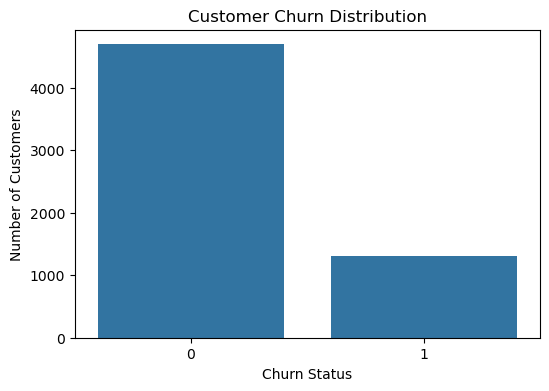

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=customers,
    x="churned"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [23]:
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)

customers["churn_date"] = pd.to_datetime(
    customers["churn_date"]
)

subscription["month"] = pd.to_datetime(
    subscription["month"]
)

In [24]:
customers[["signup_date", "churn_date"]].dtypes

signup_date    datetime64[ns]
churn_date     datetime64[ns]
dtype: object

In [27]:
subscription["month"].dtype

dtype('<M8[ns]')

In [33]:
customers_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
signup_date,6000,2024-10-04 05:08:09.600000,2023-01-01 00:00:00,2023-11-01 00:00:00,2024-10-01 00:00:00,2025-09-01 00:00:00,2026-07-01 00:00:00,NaN
monthly_price,6000.0,81.266667,29.0,29.0,79.0,79.0,199.0,63.215464
company_size_employees,6000.0,30.222333,1.0,7.0,16.0,34.0,4056.0,69.693272
monthly_active_users_pct,6000.0,0.546582,0.02,0.396,0.548,0.692,1.0,0.215935
feature_adoption_count,6000.0,4.020333,0.0,3.0,4.0,5.0,13.0,2.013603
support_tickets_90d,6000.0,1.4115,0.0,1.0,1.0,2.0,8.0,1.188586
avg_csat_score,6000.0,3.935735,1.0,3.4,3.99,4.6,5.0,0.804372
failed_payments_90d,6000.0,0.580833,0.0,0.0,0.0,1.0,2.0,0.742894
last_login_days_ago,6000.0,11.342167,0.0,3.0,8.0,16.0,125.0,12.18092
churned,6000.0,0.218,0.0,0.0,0.0,0.0,1.0,0.412922


## 2. Data Cleaning & Validation


In [32]:
customers_clean = customers.copy()
subscription_clean = subscription.copy()

In [37]:
customers_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
signup_date,6000,2024-10-04 05:08:09.600000,2023-01-01 00:00:00,2023-11-01 00:00:00,2024-10-01 00:00:00,2025-09-01 00:00:00,2026-07-01 00:00:00,NaN
monthly_price,6000.0,81.266667,29.0,29.0,79.0,79.0,199.0,63.215464
company_size_employees,6000.0,30.222333,1.0,7.0,16.0,34.0,4056.0,69.693272
monthly_active_users_pct,6000.0,0.546582,0.02,0.396,0.548,0.692,1.0,0.215935
feature_adoption_count,6000.0,4.020333,0.0,3.0,4.0,5.0,13.0,2.013603
support_tickets_90d,6000.0,1.4115,0.0,1.0,1.0,2.0,8.0,1.188586
avg_csat_score,6000.0,3.935735,1.0,3.4,3.99,4.6,5.0,0.804372
failed_payments_90d,6000.0,0.580833,0.0,0.0,0.0,1.0,2.0,0.742894
last_login_days_ago,6000.0,11.342167,0.0,3.0,8.0,16.0,125.0,12.18092
churned,6000.0,0.218,0.0,0.0,0.0,0.0,1.0,0.412922


In [38]:
print("Usage range:",
      customers_clean["monthly_active_users_pct"].min(),
      "to",
      customers_clean["monthly_active_users_pct"].max())

print("CSAT range:",
      customers_clean["avg_csat_score"].min(),
      "to",
      customers_clean["avg_csat_score"].max())

print("Support tickets range:",
      customers_clean["support_tickets_90d"].min(),
      "to",
      customers_clean["support_tickets_90d"].max())

print("Failed payments range:",
      customers_clean["failed_payments_90d"].min(),
      "to",
      customers_clean["failed_payments_90d"].max())

print("Tenure range:",
      customers_clean["tenure_months"].min(),
      "to",
      customers_clean["tenure_months"].max())

print("Lifetime revenue range:",
      customers_clean["lifetime_revenue"].min(),
      "to",
      customers_clean["lifetime_revenue"].max())

Usage range: 0.02 to 1.0
CSAT range: 1.0 to 5.0
Support tickets range: 0 to 8
Failed payments range: 0 to 2
Tenure range: 1 to 44
Lifetime revenue range: 29 to 8756


In [39]:
customers_clean[
    customers_clean["company_size_employees"] > 500
][[
    "customer_id",
    "plan_tier",
    "contract_type",
    "company_size_employees",
    "monthly_price",
    "lifetime_revenue",
    "churned"
]].sort_values(
    "company_size_employees",
    ascending=False
)

,customer_id,plan_tier,contract_type,company_size_employees,monthly_price,lifetime_revenue,churned
2558,C02559,Basic,2-Year,4056,29,1044,0
4838,C04839,Pro,Month-to-month,995,79,1659,0
1934,C01935,Pro,2-Year,753,79,3397,0
251,C00252,Basic,Month-to-month,734,29,319,0
3664,C03665,Enterprise,Month-to-month,681,199,2786,0
2154,C02155,Enterprise,1-Year,625,199,796,0
4710,C04711,Basic,Month-to-month,549,29,145,0
2738,C02739,Basic,1-Year,517,29,145,0
4309,C04310,Pro,Month-to-month,504,79,237,0


In [40]:
customers_clean.groupby("churned")["churn_date"].apply(
    lambda x: x.notna().sum()
)

churned
0       0
1    1308
Name: churn_date, dtype: int64

In [41]:
customers_clean.groupby(
    customers_clean["churn_date"].notna()
)["churned"].value_counts()

churn_date  churned
False       0          4692
True        1          1308
Name: count, dtype: int64

In [43]:
customers_clean.to_csv(
    "customers_clean.csv",
    index=False
)

subscription_clean.to_csv(
    "subscription_monthly_clean.csv",
    index=False
)

In [44]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
customers["churn_date"] = pd.to_datetime(customers["churn_date"])
subscription["month"] = pd.to_datetime(subscription["month"])

In [45]:
customers_clean
subscription_clean

,customer_id,month,tenure_month,is_active,mrr
0,C00001,2024-07-01,1,1,79
1,C00001,2024-08-01,2,1,79
2,C00001,2024-09-01,3,1,79
3,C00001,2024-10-01,4,1,79
4,C00001,2024-11-01,5,1,79
...,...,...,...,...,...
115940,C06000,2026-04-01,28,1,199
115941,C06000,2026-05-01,29,1,199
115942,C06000,2026-06-01,30,1,199
115943,C06000,2026-07-01,31,1,199


In [48]:
subscription_clean["mrr"].describe()

count    115945.000000
mean         81.801501
std          63.184526
min          29.000000
25%          29.000000
50%          79.000000
75%          79.000000
max         199.000000
Name: mrr, dtype: float64

In [49]:
subscription_clean.groupby("customer_id")["tenure_month"].agg(
    ["min", "max", "count"]
).head(10)

,min,max,count
customer_id,,,
C00001,1,26,26
C00002,1,21,21
C00003,1,6,6
C00004,1,9,9
C00005,1,10,10
C00006,1,21,21
C00007,1,30,30
C00008,1,20,20
C00009,1,7,7


In [50]:
subscription_clean["customer_id"].nunique()

6000

In [51]:
subscription_clean.duplicated(
    subset=["customer_id", "month"]
).sum()

0

In [52]:
subscription_clean["is_active"].value_counts()

is_active
1    115945
Name: count, dtype: int64

In [53]:
subscription_clean.groupby("is_active")["mrr"].agg(
    ["count", "min", "max", "mean"]
)

,count,min,max,mean
is_active,,,,
1,115945,29,199,81.801501


## 3. Exploratory Data Analysis


In [54]:
customers_clean["contract_type"].value_counts()

contract_type
Month-to-month    3257
1-Year            1822
2-Year             921
Name: count, dtype: int64

In [55]:
customers_clean["contract_type"].value_counts(normalize=True) * 100

contract_type
Month-to-month    54.283333
1-Year            30.366667
2-Year            15.350000
Name: proportion, dtype: float64

In [56]:
contract_churn = (
    customers_clean
    .groupby("contract_type")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

contract_churn["churn_rate"] = (
    contract_churn["churn_rate"] * 100
)

contract_churn

,contract_type,customers,churned,churn_rate
0,1-Year,1822,323,17.727772
1,2-Year,921,135,14.657980
2,Month-to-month,3257,850,26.097636


In [58]:
contract_churn = contract_churn.sort_values(
    "churn_rate",
    ascending=False
)

contract_churn

,contract_type,customers,churned,churn_rate
2,Month-to-month,3257,850,26.097636
0,1-Year,1822,323,17.727772
1,2-Year,921,135,14.657980


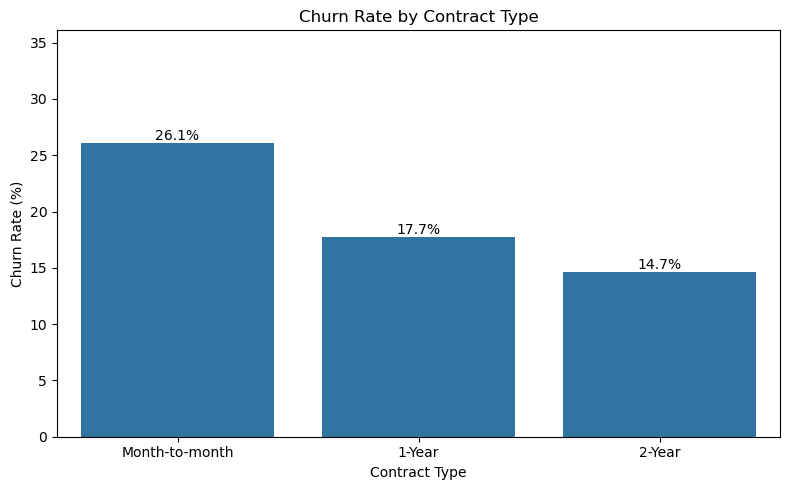

In [59]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_churn,
    x="contract_type",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, contract_churn["churn_rate"].max() + 10)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

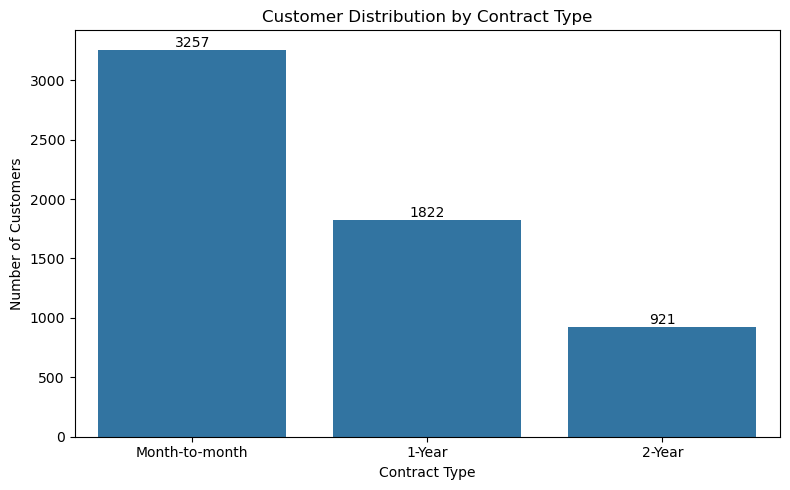

In [60]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=customers_clean,
    x="contract_type"
)

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [63]:
customers_clean["plan_tier"].value_counts()

plan_tier
Basic         2632
Pro           2158
Enterprise    1210
Name: count, dtype: int64

In [64]:
plan_churn = (
    customers_clean
    .groupby("plan_tier")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

plan_churn["churn_rate"] *= 100

plan_churn = plan_churn.sort_values(
    "churn_rate",
    ascending=False
)

plan_churn

,plan_tier,customers,churned,churn_rate
1,Enterprise,1210,271,22.396694
0,Basic,2632,572,21.732523
2,Pro,2158,465,21.547729


In [65]:
customers_clean["tenure_months"].describe()

count    6000.000000
mean       19.324167
std        12.484246
min         1.000000
25%         8.000000
50%        17.000000
75%        29.000000
max        44.000000
Name: tenure_months, dtype: float64

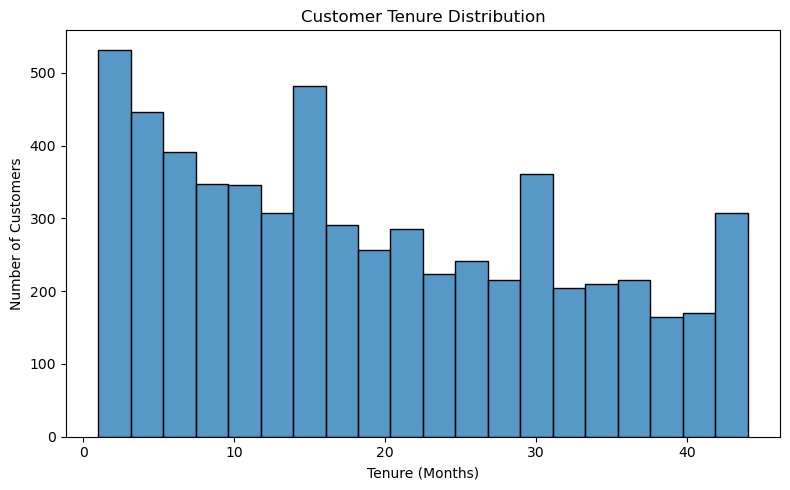

In [66]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=customers_clean,
    x="tenure_months",
    bins=20
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [67]:
customers_clean["tenure_bucket"] = pd.cut(
    customers_clean["tenure_months"],
    bins=[0, 6, 12, 24, 36, 48],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months"
    ]
)

In [68]:
customers_clean["tenure_bucket"].value_counts().sort_index()

tenure_bucket
0-6 months      1159
7-12 months     1061
13-24 months    1691
25-36 months    1341
37-48 months     748
Name: count, dtype: int64

In [69]:
tenure_churn = (
    customers_clean
    .groupby("tenure_bucket", observed=True)
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

tenure_churn["churn_rate"] *= 100

tenure_churn

,tenure_bucket,customers,churned,churn_rate
0,0-6 months,1159,474,40.897325
1,7-12 months,1061,351,33.081998
2,13-24 months,1691,329,19.455943
3,25-36 months,1341,130,9.694258
4,37-48 months,748,24,3.208556


In [70]:
customers_clean["usage_tercile"] = pd.qcut(
    customers_clean["monthly_active_users_pct"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [71]:
usage_churn = (
    customers_clean
    .groupby("usage_tercile", observed=True)
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

usage_churn["churn_rate"] *= 100

usage_churn

,usage_tercile,customers,churned,churn_rate
0,Low,2012,584,29.025845
1,Medium,1996,396,19.839679
2,High,1992,328,16.465863


In [72]:
customers_clean["csat_bucket"] = pd.cut(
    customers_clean["avg_csat_score"],
    bins=[0, 2, 3, 4, 5],
    labels=[
        "Low (1-2)",
        "Below Average (2-3)",
        "Good (3-4)",
        "High (4-5)"
    ],
    include_lowest=True
)

In [73]:
csat_churn = (
    customers_clean
    .groupby("csat_bucket", observed=True)
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

csat_churn["churn_rate"] *= 100

csat_churn

,csat_bucket,customers,churned,churn_rate
0,Low (1-2),86,44,51.162791
1,Below Average (2-3),713,226,31.697055
2,Good (3-4),2242,564,25.156111
3,High (4-5),2959,474,16.018925


In [74]:
support_churn = (
    customers_clean
    .groupby("support_tickets_90d")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

support_churn["churn_rate"] *= 100

support_churn

,support_tickets_90d,customers,churned,churn_rate
0,0,1447,220,15.203870
1,1,2092,414,19.789675
2,2,1445,360,24.913495
3,3,705,198,28.085106
4,4,218,68,31.192661
5,5,64,31,48.437500
6,6,24,14,58.333333
7,7,4,3,75.000000
8,8,1,0,0.000000


In [75]:
payment_failure_churn = (
    customers_clean
    .groupby("failed_payments_90d")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

payment_failure_churn["churn_rate"] *= 100

payment_failure_churn

,failed_payments_90d,customers,churned,churn_rate
0,0,3440,463,13.459302
1,1,1635,434,26.544343
2,2,925,411,44.432432


In [76]:
customers_clean["login_recency_bucket"] = pd.cut(
    customers_clean["last_login_days_ago"],
    bins=[-1, 7, 14, 30, 60, float("inf")],
    labels=[
        "0-7 days",
        "8-14 days",
        "15-30 days",
        "31-60 days",
        "60+ days"
    ]
)

login_churn = (
    customers_clean
    .groupby("login_recency_bucket", observed=True)
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

login_churn["churn_rate"] *= 100

login_churn

,login_recency_bucket,customers,churned,churn_rate
0,0-7 days,2982,587,19.684775
1,8-14 days,1345,307,22.825279
2,15-30 days,1235,286,23.157895
3,31-60 days,401,116,28.927681
4,60+ days,37,12,32.432432


In [77]:
feature_churn = (
    customers_clean
    .groupby("feature_adoption_count")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

feature_churn["churn_rate"] *= 100

feature_churn

,feature_adoption_count,customers,churned,churn_rate
0,0,117,30,25.641026
1,1,437,158,36.155606
2,2,854,218,25.526932
3,3,1193,288,24.140821
4,4,1128,244,21.631206
5,5,947,187,19.746568
6,6,630,97,15.396825
7,7,388,53,13.659794
8,8,170,16,9.411765
9,9,85,15,17.647059


In [78]:
country_churn = (
    customers_clean
    .groupby("country")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

country_churn["churn_rate"] *= 100

country_churn = country_churn.sort_values(
    "churn_rate",
    ascending=False
)

country_churn

,country,customers,churned,churn_rate
0,Australia,600,134,22.333333
4,UK,908,201,22.136564
3,India,1207,264,21.872411
2,Germany,758,165,21.767810
5,USA,1841,400,21.727322
1,Canada,686,144,20.991254


In [79]:
payment_method_churn = (
    customers_clean
    .groupby("payment_method")
    .agg(
        customers=("customer_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

payment_method_churn["churn_rate"] *= 100

payment_method_churn = payment_method_churn.sort_values(
    "churn_rate",
    ascending=False
)

payment_method_churn

,payment_method,customers,churned,churn_rate
0,ACH/Bank Transfer,1192,272,22.818792
1,Credit Card,3292,739,22.448360
3,PayPal,912,191,20.942982
2,Manual Invoice,604,106,17.549669


## 4. Business KPIs & Revenue Analysis


In [80]:
total_customers = customers_clean["customer_id"].nunique()
churned_customers = customers_clean["churned"].sum()

customer_churn_rate = (
    churned_customers / total_customers
) * 100

customer_churn_rate

21.8

In [81]:
retention_rate = 100 - customer_churn_rate

retention_rate

78.2

In [82]:
mrr_lost = (
    customers_clean
    .loc[customers_clean["churned"] == 1, "monthly_price"]
    .sum()
)

mrr_lost

107252

In [83]:
total_mrr = customers_clean["monthly_price"].sum()

revenue_churn_rate = (
    mrr_lost / total_mrr
) * 100

total_mrr, revenue_churn_rate

(487600, 21.995898277276456)

In [84]:
arpu = (
    customers_clean["monthly_price"].sum()
    / customers_clean["customer_id"].nunique()
)

arpu

81.26666666666667

In [85]:
churned_arpu = (
    customers_clean
    .loc[customers_clean["churned"] == 1, "monthly_price"]
    .mean()
)

churned_arpu

81.99694189602447

In [86]:
arpu_comparison = pd.DataFrame({
    "Segment": ["All Customers", "Churned Customers"],
    "ARPU": [
        customers_clean["monthly_price"].mean(),
        customers_clean.loc[
            customers_clean["churned"] == 1,
            "monthly_price"
        ].mean()
    ]
})

arpu_comparison

,Segment,ARPU
0,All Customers,81.266667
1,Churned Customers,81.996942


In [87]:
customers_clean["clv"] = (
    customers_clean["monthly_price"]
    * customers_clean["tenure_months"]
)

customers_clean["clv"].describe()

count    6000.000000
mean     1580.745833
std      1785.274798
min        29.000000
25%       406.000000
50%       928.000000
75%      2133.000000
max      8756.000000
Name: clv, dtype: float64

In [88]:
clv_by_churn = (
    customers_clean
    .groupby("churned")
    .agg(
        customers=("customer_id", "count"),
        avg_clv=("clv", "mean"),
        median_clv=("clv", "median")
    )
    .reset_index()
)

clv_by_churn["status"] = clv_by_churn["churned"].map({
    0: "Retained",
    1: "Churned"
})

clv_by_churn

,churned,customers,avg_clv,median_clv,status
0,0,4692,1750.003197,1044.0,Retained
1,1,1308,973.593272,522.0,Churned


In [89]:
contract_kpis = (
    customers_clean
    .groupby("contract_type")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        total_mrr=("monthly_price", "sum"),
        mrr_lost=("monthly_price", lambda x:
                  x[customers_clean.loc[x.index, "churned"] == 1].sum())
    )
    .reset_index()
)

contract_kpis["churn_rate"] = (
    contract_kpis["churned_customers"]
    / contract_kpis["customers"]
) * 100

contract_kpis["revenue_churn_rate"] = (
    contract_kpis["mrr_lost"]
    / contract_kpis["total_mrr"]
) * 100

contract_kpis

,contract_type,customers,churned_customers,total_mrr,mrr_lost,churn_rate,revenue_churn_rate
0,1-Year,1822,323,149248,27687,17.727772,18.551002
1,2-Year,921,135,74859,11705,14.657980,15.636062
2,Month-to-month,3257,850,263493,67860,26.097636,25.754005


In [90]:
plan_kpis = (
    customers_clean
    .groupby("plan_tier")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        total_mrr=("monthly_price", "sum"),
        mrr_lost=("monthly_price", lambda x:
                  x[customers_clean.loc[x.index, "churned"] == 1].sum())
    )
    .reset_index()
)

plan_kpis["churn_rate"] = (
    plan_kpis["churned_customers"]
    / plan_kpis["customers"]
) * 100

plan_kpis["revenue_churn_rate"] = (
    plan_kpis["mrr_lost"]
    / plan_kpis["total_mrr"]
) * 100

plan_kpis

,plan_tier,customers,churned_customers,total_mrr,mrr_lost,churn_rate,revenue_churn_rate
0,Basic,2632,572,76328,16588,21.732523,21.732523
1,Enterprise,1210,271,240790,53929,22.396694,22.396694
2,Pro,2158,465,170482,36735,21.547729,21.547729


## 5. Statistical Inference


In [91]:
from scipy.stats import chi2_contingency

In [92]:
contract_table = pd.crosstab(
    customers_clean["contract_type"],
    customers_clean["churned"]
)

contract_table

churned,0,1
contract_type,,
1-Year,1499,323
2-Year,786,135
Month-to-month,2407,850


In [93]:
chi2, p_value, dof, expected = chi2_contingency(contract_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 80.56782749900383
p-value: 3.1982952209390277e-18
Degrees of freedom: 2


In [94]:
plan_table = pd.crosstab(
    customers_clean["plan_tier"],
    customers_clean["churned"]
)

plan_table

churned,0,1
plan_tier,,
Basic,2060,572
Enterprise,939,271
Pro,1693,465


In [95]:
chi2_plan, p_value_plan, dof_plan, expected_plan = chi2_contingency(plan_table)

print("Chi-square statistic:", chi2_plan)
print("p-value:", p_value_plan)
print("Degrees of freedom:", dof_plan)

Chi-square statistic: 0.3403020369734811
p-value: 0.8435374172325367
Degrees of freedom: 2


In [96]:
from scipy.stats import pointbiserialr

In [97]:
r_usage, p_usage = pointbiserialr(
    customers_clean["churned"],
    customers_clean["monthly_active_users_pct"]
)

print("Usage vs Churn")
print("Correlation:", r_usage)
print("p-value:", p_usage)

Usage vs Churn
Correlation: -0.1327433274614401
p-value: 5.384789284623825e-25


In [98]:
r_csat, p_csat = pointbiserialr(
    customers_clean["churned"],
    customers_clean["avg_csat_score"]
)

print("CSAT vs Churn")
print("Correlation:", r_csat)
print("p-value:", p_csat)

CSAT vs Churn
Correlation: -0.16611652250543663
p-value: 2.2084997234490903e-38


In [99]:
r_tickets, p_tickets = pointbiserialr(
    customers_clean["churned"],
    customers_clean["support_tickets_90d"]
)

print("Support Tickets vs Churn")
print("Correlation:", r_tickets)
print("p-value:", p_tickets)

Support Tickets vs Churn
Correlation: 0.14053002885447968
p-value: 7.631083027115965e-28


In [100]:
import statsmodels.formula.api as smf

In [101]:
model = smf.logit(
    formula="""
    churned ~
    C(contract_type, Treatment(reference="2-Year")) +
    C(plan_tier, Treatment(reference="Basic")) +
    monthly_active_users_pct +
    avg_csat_score +
    support_tickets_90d +
    failed_payments_90d +
    last_login_days_ago +
    feature_adoption_count +
    monthly_price
    """,
    data=customers_clean
).fit()

Optimization terminated successfully.
         Current function value: 0.432033
         Iterations 7


In [102]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5988
Method:                           MLE   Df Model:                           11
Date:                Thu, 10 Sep 2026   Pseudo R-squ.:                  0.1761
Time:                        17:25:25   Log-Likelihood:                -2592.2
converged:                       True   LL-Null:                       -3146.2
Covariance Type:            nonrobust   LLR p-value:                1.086e-230
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                             0.8132   3.85e+05   2.11e-06  

In [103]:
import numpy as np

odds_ratios = np.exp(model.params)

odds_ratios

Intercept                                                            2.255078
C(contract_type, Treatment(reference="2-Year"))[T.1-Year]            1.265239
C(contract_type, Treatment(reference="2-Year"))[T.Month-to-month]    2.408038
C(plan_tier, Treatment(reference="Basic"))[T.Enterprise]             0.876186
C(plan_tier, Treatment(reference="Basic"))[T.Pro]                    0.978018
monthly_active_users_pct                                             0.139189
avg_csat_score                                                       0.551779
support_tickets_90d                                                  1.368644
failed_payments_90d                                                  2.641199
last_login_days_ago                                                  1.016912
feature_adoption_count                                               0.819408
monthly_price                                                        1.001081
dtype: float64

In [104]:
inference_results = pd.DataFrame({
    "Feature": model.params.index,
    "Coefficient": model.params.values,
    "Odds_Ratio": np.exp(model.params.values),
    "P_Value": model.pvalues.values,
    "CI_Lower": np.exp(model.conf_int()[0].values),
    "CI_Upper": np.exp(model.conf_int()[1].values)
})

inference_results

C:\Users\patel\AppData\Local\Temp\ipykernel_972\656162478.py:7: RuntimeWarning: overflow encountered in exp
  "CI_Upper": np.exp(model.conf_int()[1].values)


,Feature,Coefficient,Odds_Ratio,P_Value,CI_Lower,CI_Upper
0,Intercept,0.813185,2.255078,9.999983e-01,0.000000,inf
1,"C(contract_type, Treatment(reference=""2-Year"")...",0.235261,1.265239,5.306787e-02,0.996892,1.605822
2,"C(contract_type, Treatment(reference=""2-Year"")...",0.878812,2.408038,2.709240e-15,1.936499,2.994398
3,"C(plan_tier, Treatment(reference=""Basic""))[T.E...",-0.132176,0.876186,1.000000e+00,0.000000,inf
4,"C(plan_tier, Treatment(reference=""Basic""))[T.Pro]",-0.022227,0.978018,1.000000e+00,0.000000,inf
5,monthly_active_users_pct,-1.971921,0.139189,6.012813e-33,0.100744,0.192305
6,avg_csat_score,-0.594607,0.551779,6.824040e-43,0.506873,0.600664
7,support_tickets_90d,0.313821,1.368644,1.243980e-28,1.294872,1.446619
8,failed_payments_90d,0.971233,2.641199,7.968665e-102,2.416645,2.886617
9,last_login_days_ago,0.016771,1.016912,4.012310e-10,1.011581,1.022271


In [105]:
inference_results.sort_values("P_Value")

,Feature,Coefficient,Odds_Ratio,P_Value,CI_Lower,CI_Upper
8,failed_payments_90d,0.971233,2.641199,7.968665e-102,2.416645,2.886617
6,avg_csat_score,-0.594607,0.551779,6.824040e-43,0.506873,0.600664
5,monthly_active_users_pct,-1.971921,0.139189,6.012813e-33,0.100744,0.192305
7,support_tickets_90d,0.313821,1.368644,1.243980e-28,1.294872,1.446619
10,feature_adoption_count,-0.199173,0.819408,1.163170e-27,0.790579,0.849288
2,"C(contract_type, Treatment(reference=""2-Year"")...",0.878812,2.408038,2.709240e-15,1.936499,2.994398
9,last_login_days_ago,0.016771,1.016912,4.012310e-10,1.011581,1.022271
1,"C(contract_type, Treatment(reference=""2-Year"")...",0.235261,1.265239,5.306787e-02,0.996892,1.605822
0,Intercept,0.813185,2.255078,9.999983e-01,0.000000,inf
11,monthly_price,0.001080,1.001081,9.999999e-01,0.000000,inf


## 6. Survival Analysis

Kaplan-Meier curves are used to compare retention over time, followed by Cox proportional hazards modeling to quantify relative churn hazard.


In [107]:
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

In [108]:
survival_df = customers_clean[
    ["customer_id", "tenure_months", "churned"]
].copy()

survival_df.head()

,customer_id,tenure_months,churned
0,C00001,26,0
1,C00002,21,0
2,C00003,6,0
3,C00004,9,1
4,C00005,10,0


In [109]:
survival_df = survival_df.rename(
    columns={
        "tenure_months": "duration",
        "churned": "event"
    }
)

survival_df.head()

,customer_id,duration,event
0,C00001,26,0
1,C00002,21,0
2,C00003,6,0
3,C00004,9,1
4,C00005,10,0


In [110]:
print("Customers:", survival_df["customer_id"].nunique())
print("Events:", survival_df["event"].sum())
print("Censored:", (survival_df["event"] == 0).sum())
print("Maximum duration:", survival_df["duration"].max())

Customers: 6000
Events: 1308
Censored: 4692
Maximum duration: 44


In [111]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["duration"],
    event_observed=survival_df["event"],
    label="All Customers"
)

<lifelines.KaplanMeierFitter:"All Customers", fitted with 6000 total observations, 4692 right-censored observations>

In [112]:
kmf.survival_function_.head(10)

,All Customers
timeline,
0.0,1.000000
1.0,0.987000
2.0,0.975167
3.0,0.959276
4.0,0.943662
5.0,0.930176
6.0,0.917578
7.0,0.902604
8.0,0.890710


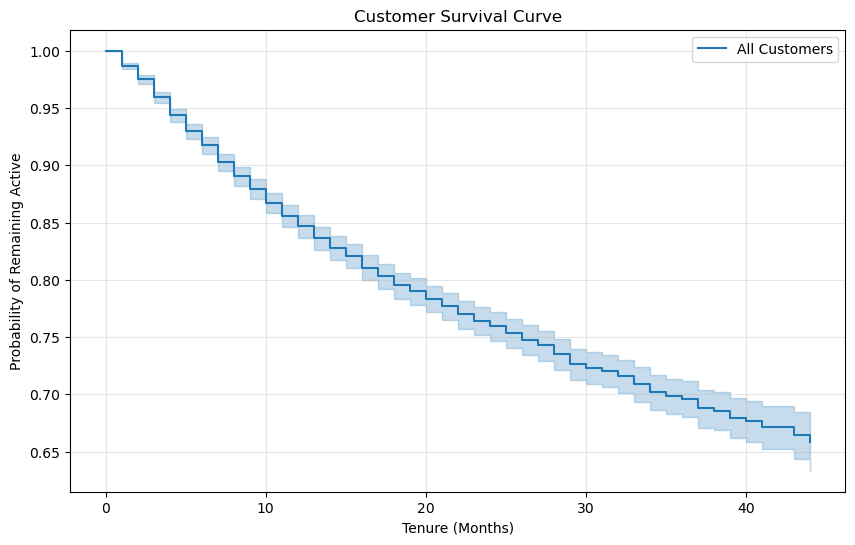

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

kmf.plot_survival_function()

plt.title("Customer Survival Curve")
plt.xlabel("Tenure (Months)")
plt.ylabel("Probability of Remaining Active")
plt.grid(alpha=0.3)

plt.show()

In [114]:
print("Median survival time:",
      kmf.median_survival_time_)

Median survival time: inf


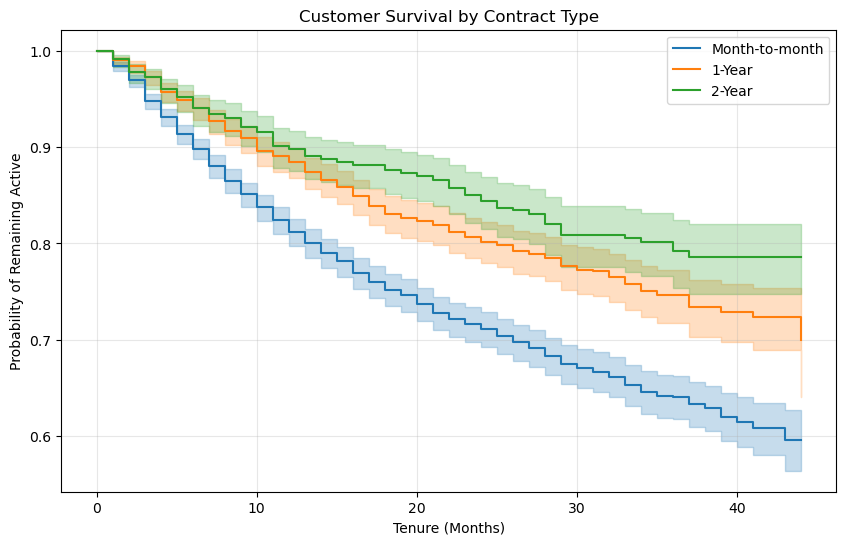

In [115]:
plt.figure(figsize=(10, 6))

for contract in survival_df.merge(
    customers_clean[["customer_id", "contract_type"]],
    on="customer_id"
)["contract_type"].unique():

    group = survival_df.merge(
        customers_clean[["customer_id", "contract_type"]],
        on="customer_id"
    )

    group = group[group["contract_type"] == contract]

    kmf_contract = KaplanMeierFitter()

    kmf_contract.fit(
        durations=group["duration"],
        event_observed=group["event"],
        label=contract
    )

    kmf_contract.plot_survival_function()

plt.title("Customer Survival by Contract Type")
plt.xlabel("Tenure (Months)")
plt.ylabel("Probability of Remaining Active")
plt.grid(alpha=0.3)

plt.show()

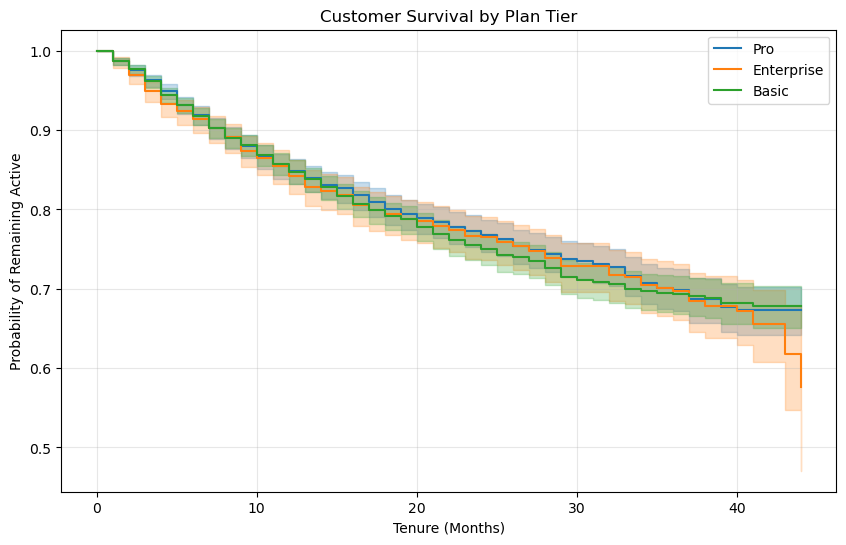

In [116]:
merged_survival = survival_df.merge(
    customers_clean[["customer_id", "plan_tier"]],
    on="customer_id"
)

plt.figure(figsize=(10, 6))

for plan in merged_survival["plan_tier"].unique():

    group = merged_survival[
        merged_survival["plan_tier"] == plan
    ]

    kmf_plan = KaplanMeierFitter()

    kmf_plan.fit(
        durations=group["duration"],
        event_observed=group["event"],
        label=plan
    )

    kmf_plan.plot_survival_function()

plt.title("Customer Survival by Plan Tier")
plt.xlabel("Tenure (Months)")
plt.ylabel("Probability of Remaining Active")
plt.grid(alpha=0.3)

plt.show()

In [117]:
cox_df = survival_df.merge(
    customers_clean[
        [
            "customer_id",
            "contract_type",
            "plan_tier",
            "monthly_active_users_pct",
            "avg_csat_score",
            "support_tickets_90d",
            "failed_payments_90d",
            "last_login_days_ago",
            "feature_adoption_count",
            "monthly_price"
        ]
    ],
    on="customer_id"
)

cox_df.head()

,customer_id,duration,event,contract_type,plan_tier,monthly_active_users_pct,avg_csat_score,support_tickets_90d,failed_payments_90d,last_login_days_ago,feature_adoption_count,monthly_price
0,C00001,26,0,Month-to-month,Pro,0.578,3.23,3,0,3,3,79
1,C00002,21,0,1-Year,Enterprise,0.456,4.39,0,0,4,2,199
2,C00003,6,0,Month-to-month,Enterprise,0.365,4.78,3,1,4,5,199
3,C00004,9,1,1-Year,Basic,0.409,3.70,2,1,25,1,29
4,C00005,10,0,1-Year,Pro,0.508,4.62,1,0,9,2,79


In [118]:
cox_df = pd.get_dummies(
    cox_df,
    columns=["contract_type", "plan_tier"],
    drop_first=False
)

cox_df.head()

,customer_id,duration,event,monthly_active_users_pct,avg_csat_score,support_tickets_90d,failed_payments_90d,last_login_days_ago,feature_adoption_count,monthly_price,contract_type_1-Year,contract_type_2-Year,contract_type_Month-to-month,plan_tier_Basic,plan_tier_Enterprise,plan_tier_Pro
0,C00001,26,0,0.578,3.23,3,0,3,3,79,False,False,True,False,False,True
1,C00002,21,0,0.456,4.39,0,0,4,2,199,True,False,False,False,True,False
2,C00003,6,0,0.365,4.78,3,1,4,5,199,False,False,True,False,True,False
3,C00004,9,1,0.409,3.70,2,1,25,1,29,True,False,False,True,False,False
4,C00005,10,0,0.508,4.62,1,0,9,2,79,True,False,False,False,False,True


In [119]:
cox_df.columns

Index(['customer_id', 'duration', 'event', 'monthly_active_users_pct',
       'avg_csat_score', 'support_tickets_90d', 'failed_payments_90d',
       'last_login_days_ago', 'feature_adoption_count', 'monthly_price',
       'contract_type_1-Year', 'contract_type_2-Year',
       'contract_type_Month-to-month', 'plan_tier_Basic',
       'plan_tier_Enterprise', 'plan_tier_Pro'],
      dtype='object')

In [120]:
cox_df = cox_df.drop(
    columns=[
        "contract_type_2-Year",
        "plan_tier_Basic"
    ]
)

In [121]:
cox_df = cox_df.astype({
    col: "int"
    for col in cox_df.select_dtypes(include="bool").columns
})

In [122]:
cox_df.dtypes

customer_id                      object
duration                          int64
event                             int64
monthly_active_users_pct        float64
avg_csat_score                  float64
support_tickets_90d               int64
failed_payments_90d               int64
last_login_days_ago               int64
feature_adoption_count            int64
monthly_price                     int64
contract_type_1-Year              int32
contract_type_Month-to-month      int32
plan_tier_Enterprise              int32
plan_tier_Pro                     int32
dtype: object

In [123]:
cph = CoxPHFitter()

cph.fit(
    cox_df.drop(columns=["customer_id"]),
    duration_col="duration",
    event_col="event"
)

C:\Users\patel\anaconda3\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1530: LinAlgWarning: Ill-conditioned matrix (rcond=1.10039e-16): result may not be accurate.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)
C:\Users\patel\anaconda3\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1530: LinAlgWarning: Ill-conditioned matrix (rcond=4.84321e-17): result may not be accurate.
  inv_h_dot_g_T = spsolve(-h, g, assume_a="pos", check_finite=False)


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

In [124]:
cox_df.drop(columns=["customer_id"]).corr(numeric_only=True).round(2)

,duration,event,monthly_active_users_pct,avg_csat_score,support_tickets_90d,failed_payments_90d,last_login_days_ago,feature_adoption_count,monthly_price,contract_type_1-Year,contract_type_Month-to-month,plan_tier_Enterprise,plan_tier_Pro
duration,1.00,-0.32,0.07,0.10,-0.09,-0.16,-0.04,0.08,0.01,0.03,-0.07,0.00,0.02
event,-0.32,1.00,-0.13,-0.17,0.14,0.27,0.07,-0.13,0.01,-0.07,0.11,0.01,-0.00
monthly_active_users_pct,0.07,-0.13,1.00,-0.01,-0.01,0.01,0.01,0.00,0.01,0.00,0.02,0.01,0.00
avg_csat_score,0.10,-0.17,-0.01,1.00,-0.03,0.00,0.01,0.01,-0.01,-0.01,0.00,-0.01,-0.00
support_tickets_90d,-0.09,0.14,-0.01,-0.03,1.00,0.00,0.02,0.01,0.01,0.00,0.01,0.02,-0.02
failed_payments_90d,-0.16,0.27,0.01,0.00,0.00,1.00,-0.02,-0.00,-0.00,-0.01,0.01,-0.00,-0.00
last_login_days_ago,-0.04,0.07,0.01,0.01,0.02,-0.02,1.00,-0.00,-0.00,-0.00,0.01,-0.01,0.00
feature_adoption_count,0.08,-0.13,0.00,0.01,0.01,-0.00,-0.00,1.00,-0.02,-0.03,0.02,-0.02,0.02
monthly_price,0.01,0.01,0.01,-0.01,0.01,-0.00,-0.00,-0.02,1.00,0.01,-0.01,0.94,-0.03
contract_type_1-Year,0.03,-0.07,0.00,-0.01,0.00,-0.01,-0.00,-0.03,0.01,1.00,-0.72,0.01,0.00


In [125]:
cox_features = cox_df.drop(columns=["customer_id"])

print("Zero-variance columns:")
print(
    cox_features.columns[
        cox_features.nunique() <= 1
    ].tolist()
)

Zero-variance columns:
[]


In [126]:
corr_matrix = cox_features.corr()

high_corr = (
    corr_matrix
    .where(
        (corr_matrix.abs() > 0.8) &
        (corr_matrix.abs() < 1)
    )
    .stack()
    .sort_values(ascending=False)
)

high_corr

monthly_price         plan_tier_Enterprise    0.936132
plan_tier_Enterprise  monthly_price           0.936132
dtype: float64

In [127]:
cox_simple = survival_df.merge(
    customers_clean[
        [
            "customer_id",
            "contract_type",
            "monthly_active_users_pct",
            "avg_csat_score",
            "support_tickets_90d",
            "failed_payments_90d",
            "last_login_days_ago",
            "feature_adoption_count"
        ]
    ],
    on="customer_id"
)

In [128]:
cox_simple = pd.get_dummies(
    cox_simple,
    columns=["contract_type"],
    drop_first=False
)

In [129]:
cox_simple.columns

Index(['customer_id', 'duration', 'event', 'monthly_active_users_pct',
       'avg_csat_score', 'support_tickets_90d', 'failed_payments_90d',
       'last_login_days_ago', 'feature_adoption_count', 'contract_type_1-Year',
       'contract_type_2-Year', 'contract_type_Month-to-month'],
      dtype='object')

In [130]:
cox_simple = cox_simple.drop(
    columns=["contract_type_2-Year"]
)

In [131]:
cox_simple = cox_simple.astype({
    col: "int"
    for col in cox_simple.select_dtypes(include="bool").columns
})

In [132]:
cph = CoxPHFitter(penalizer=0.01)

cph.fit(
    cox_simple.drop(columns=["customer_id"]),
    duration_col="duration",
    event_col="event"
)

<lifelines.CoxPHFitter: fitted with 6000 total observations, 4692 right-censored observations>

In [133]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6000 total observations, 4692 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6000
number of events observed = 1308
   partial log-likelihood = -10166.76
         time fit was run = 2026-09-10 15:53:22 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
monthly_active_users_pct     -1.69      0.18      0.13           -1.94           -1.44                0.14                0.24
avg_csat_score               -0.50      0.61      0.03           -0.56           -0.43                0.57                0.65
support_tickets_90d           0.27      1.31      0.02            0.23            0.31                1.26                1.36
failed_payments_90d           0.84      2.32      0.03            0.77            0.91                2.17                2.48
last_login_days_ago           0.01      1.01      0.00            0.01            0.02                1.01                1.02
feature_adoption_count       -0.16      0.85      0.01           -0.19           -0.14                0.83                0.87
contract_type_1-Year          0.18      1.20      0.09           -0.00            0.36                1.00                1.43
contract_type_Month-to-month  0.71      2.03      0.08            0.55            0.87                1.73                2.39

                              cmp to      z      p  -log2(p)
covariate                                                   
monthly_active_users_pct        0.00 -13.30 <0.005    131.69
avg_csat_score                  0.00 -15.41 <0.005    175.58
support_tickets_90d             0.00  12.82 <0.005    122.59
failed_payments_90d             0.00  24.63 <0.005    442.64
last_login_days_ago             0.00   6.40 <0.005     32.56
feature_adoption_count          0.00 -11.50 <0.005     99.28
contract_type_1-Year            0.00   1.96   0.05      4.31
contract_type_Month-to-month    0.00   8.64 <0.005     57.32
---
Concordance = 0.76
Partial AIC = 20349.51
log-likelihood ratio test = 1211.00 on 8 df
-log2(p) of ll-ratio test = 848.40

In [134]:
cox_results = pd.DataFrame({
    "Feature": cph.params_.index,
    "Coefficient": cph.params_.values,
    "Hazard_Ratio": cph.hazard_ratios_.values,
    "P_Value": cph.summary["p"].values,
    "CI_Lower": cph.confidence_intervals_["95% lower-bound"].apply(np.exp).values,
    "CI_Upper": cph.confidence_intervals_["95% upper-bound"].apply(np.exp).values
})

cox_results.sort_values("P_Value")

,Feature,Coefficient,Hazard_Ratio,P_Value,CI_Lower,CI_Upper
3,failed_payments_90d,0.839965,2.316285,5.640858e-134,2.166539,2.476382
1,avg_csat_score,-0.495044,0.609544,1.393031e-53,0.572349,0.649156
0,monthly_active_users_pct,-1.692492,0.184060,2.281399e-40,0.143433,0.236195
2,support_tickets_90d,0.269203,1.308921,1.246162e-37,1.256149,1.363910
5,feature_adoption_count,-0.163316,0.849323,1.303779e-30,0.826011,0.873293
7,contract_type_Month-to-month,0.710075,2.034145,5.557711e-18,1.731556,2.389610
4,last_login_days_ago,0.012772,1.012854,1.580258e-10,1.008898,1.016825
6,contract_type_1-Year,0.178327,1.195216,5.049948e-02,0.999612,1.429095


In [135]:
cph.check_assumptions(
    cox_simple.drop(columns=["customer_id"]),
    p_value_threshold=0.05
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'failed_payments_90d' failed the non-proportional test: p-value is 0.0347.

   Advice: with so few unique values (only 3), you can include `strata=['failed_payments_90d', ...]`
in the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[]

In [136]:
cph_stratified = CoxPHFitter(penalizer=0.01)

cph_stratified.fit(
    cox_simple.drop(columns=["customer_id"]),
    duration_col="duration",
    event_col="event",
    strata=["failed_payments_90d"]
)

<lifelines.CoxPHFitter: fitted with 6000 total observations, 4692 right-censored observations>

In [137]:
cph_stratified.print_summary()

model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,failed_payments_90d
baseline estimation,breslow
number of observations,6000
number of events observed,1308
partial log-likelihood,-8738.25
time fit was run,2026-09-10 15:55:00 UTC


In [138]:
cox_stratified_results = pd.DataFrame({
    "Feature": cph_stratified.params_.index,
    "Hazard_Ratio": cph_stratified.hazard_ratios_.values,
    "P_Value": cph_stratified.summary["p"].values,
    "CI_Lower": cph_stratified.confidence_intervals_["95% lower-bound"].apply(np.exp).values,
    "CI_Upper": cph_stratified.confidence_intervals_["95% upper-bound"].apply(np.exp).values
})

cox_stratified_results.sort_values("P_Value")

,Feature,Hazard_Ratio,P_Value,CI_Lower,CI_Upper
1,avg_csat_score,0.609249,1.540711e-53,0.572022,0.648899
0,monthly_active_users_pct,0.183286,2.049356e-40,0.142763,0.235312
2,support_tickets_90d,1.309166,1.285062e-37,1.256338,1.364215
4,feature_adoption_count,0.850250,3.979196e-30,0.826872,0.874289
6,contract_type_Month-to-month,2.030439,6.991632e-18,1.728270,2.385438
3,last_login_days_ago,1.012991,9.810309e-11,1.009038,1.016960
5,contract_type_1-Year,1.197747,4.787922e-02,1.001686,1.432183


## 7. Predictive Churn Modeling

Logistic Regression, Random Forest, and XGBoost are compared using churn-focused metrics including precision, recall, F1-score, and ROC-AUC.


In [139]:
ml_df = customers_clean.copy()

print("Shape:", ml_df.shape)
ml_df.head()

Shape: (6000, 24)


,customer_id,signup_date,plan_tier,monthly_price,contract_type,payment_method,country,industry,company_size_employees,monthly_active_users_pct,...,last_login_days_ago,churned,churn_date,tenure_months,lifetime_revenue,tenure_bucket,usage_tercile,csat_bucket,login_recency_bucket,clv
0,C00001,2024-07-01,Pro,79,Month-to-month,Manual Invoice,USA,Manufacturing,46,0.578,...,3,0,NaT,26,2054,25-36 months,Medium,Good (3-4),0-7 days,2054
1,C00002,2024-12-01,Enterprise,199,1-Year,PayPal,Australia,Marketing/Agency,13,0.456,...,4,0,NaT,21,4179,13-24 months,Medium,High (4-5),0-7 days,4179
2,C00003,2026-03-01,Enterprise,199,Month-to-month,Credit Card,USA,Healthcare,32,0.365,...,4,0,NaT,6,1194,0-6 months,Low,High (4-5),0-7 days,1194
3,C00004,2023-07-01,Basic,29,1-Year,Credit Card,Germany,Finance,32,0.409,...,25,1,2024-03-01,9,261,7-12 months,Low,Good (3-4),15-30 days,261
4,C00005,2025-11-01,Pro,79,1-Year,Credit Card,UK,Healthcare,11,0.508,...,9,0,NaT,10,790,7-12 months,Medium,High (4-5),8-14 days,790


In [140]:
features = [
    "plan_tier",
    "monthly_price",
    "contract_type",
    "payment_method",
    "country",
    "industry",
    "company_size_employees",
    "monthly_active_users_pct",
    "feature_adoption_count",
    "support_tickets_90d",
    "avg_csat_score",
    "failed_payments_90d",
    "last_login_days_ago"
]

X = ml_df[features].copy()
y = ml_df["churned"].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (6000, 13)
Target: (6000,)


In [141]:
print(y.value_counts())

print("\nPercentages:")
print(
    y.value_counts(normalize=True).mul(100).round(2)
)

churned
0    4692
1    1308
Name: count, dtype: int64

Percentages:
churned
0    78.2
1    21.8
Name: proportion, dtype: float64


In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining churn rate:", y_train.mean())
print("Testing churn rate:", y_test.mean())

Training rows: 4800
Testing rows: 1200

Training churn rate: 0.21791666666666668
Testing churn rate: 0.21833333333333332


In [145]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "monthly_price",
    "company_size_employees",
    "monthly_active_users_pct",
    "feature_adoption_count",
    "support_tickets_90d",
    "avg_csat_score",
    "failed_payments_90d",
    "last_login_days_ago"
]

categorical_features = [
    "plan_tier",
    "contract_type",
    "payment_method",
    "country",
    "industry"
]

In [146]:
from sklearn.pipeline import Pipeline

In [147]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [148]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [149]:
class_weight="balanced"

In [150]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [151]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['monthly_price',
                                                   'company_size_employees',
                                                   'monthly_active_users_pct',
                                                   'feature_adoption_count',
                                                   'support_tickets_90d',
                                                   'avg_csat_score',
                                                   'failed_payments_90d',
                                                   'last_login_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['plan_tier', 'contract_type',
                                                   'payment_method', 'country',
                                                   'industry'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [152]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [153]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.6983
Precision: 0.3918
Recall   : 0.6908
F1 Score : 0.5
ROC-AUC  : 0.7789


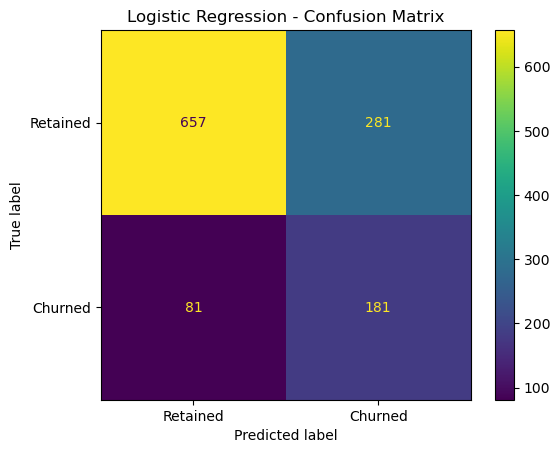

In [154]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [155]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [156]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['monthly_price',
                                                   'company_size_employees',
                                                   'monthly_active_users_pct',
                                                   'feature_adoption_count',
                                                   'support_tickets_90d',
                                                   'avg_csat_score',
                                                   'failed_payments_90d',
                                                   'last_login_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['plan_tier', 'contract_type',
                                                   'payment_method', 'country',
                                                   'industry'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [157]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [159]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest
-------------
Accuracy : 0.7508
Precision: 0.4467
Recall   : 0.5916
F1 Score : 0.509
ROC-AUC  : 0.7602


In [162]:
from xgboost import XGBClassifier

In [164]:
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("Scale positive weight:", scale_pos_weight)

Scale positive weight: 3.5889101338432123


In [165]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [166]:
xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['monthly_price',
                                                   'company_size_employees',
                                                   'monthly_active_users_pct',
                                                   'feature_adoption_count',
                                                   'support_tickets_90d',
                                                   'avg_csat_score',
                                                   'failed_payments_90d',
                                                   'last_login_days_ago']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   Sim...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [167]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [168]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost")
print("-------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_auc, 4))

XGBoost
-------
Accuracy : 0.7308
Precision: 0.4212
Recall   : 0.6221
F1 Score : 0.5023
ROC-AUC  : 0.7598


## 8. Model Interpretation


In [169]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Odds_Ratio"] = np.exp(
    feature_importance["Coefficient"]
)

feature_importance["Abs_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
2,num__monthly_active_users_pct,-1.841358,0.158602,1.841358
6,num__failed_payments_90d,0.958493,2.607762,0.958493
5,num__avg_csat_score,-0.599201,0.549250,0.599201
13,cat__contract_type_Month-to-month,0.452750,1.572631,0.452750
12,cat__contract_type_2-Year,-0.304344,0.737607,0.304344
4,num__support_tickets_90d,0.281197,1.324715,0.281197
16,cat__payment_method_Manual Invoice,-0.240843,0.785965,0.240843
3,num__feature_adoption_count,-0.206068,0.813778,0.206068
20,cat__country_Germany,-0.166253,0.846832,0.166253
14,cat__payment_method_ACH/Bank Transfer,0.148064,1.159588,0.148064


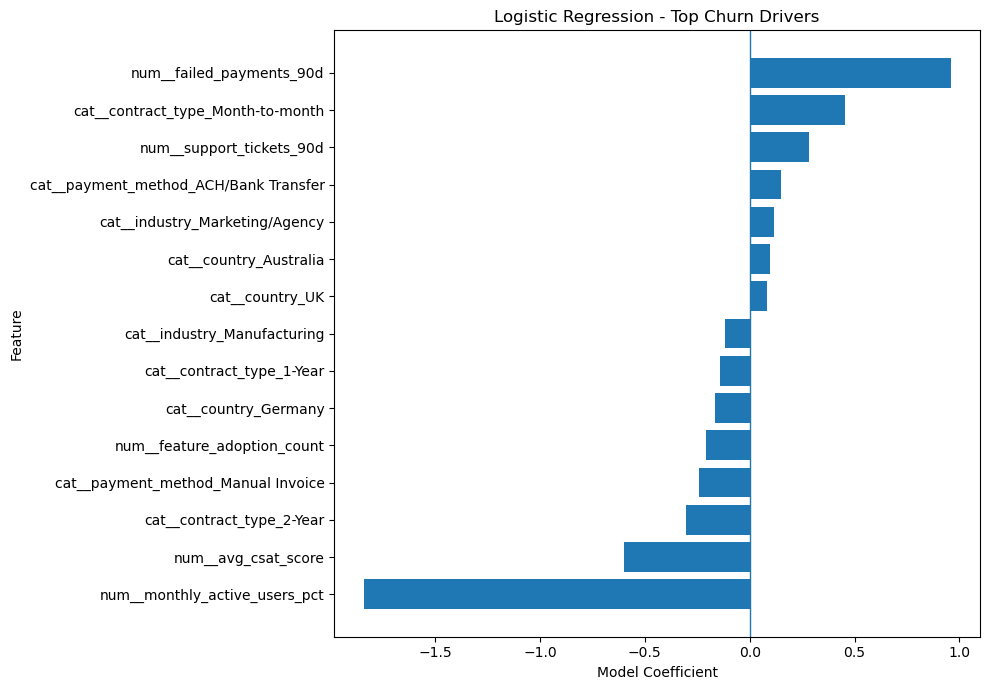

In [170]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Logistic Regression - Top Churn Drivers")
plt.xlabel("Model Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [172]:
from sklearn.metrics import classification_report

In [173]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Retained", "Churned"]
))

              precision    recall  f1-score   support

    Retained       0.89      0.70      0.78       938
     Churned       0.39      0.69      0.50       262

    accuracy                           0.70      1200
   macro avg       0.64      0.70      0.64      1200
weighted avg       0.78      0.70      0.72      1200



## 9. Customer Risk Scoring

The selected Logistic Regression model is used to generate churn probabilities. Active customers are then grouped into Low, Medium, and High risk tiers and prioritized using expected MRR at risk.


In [174]:
# Generate churn probability for each customer in the test set

churn_probability = logistic_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df["churn_probability"] = churn_probability
risk_df["actual_churn"] = y_test.values

risk_df.head()

,plan_tier,monthly_price,contract_type,payment_method,country,industry,company_size_employees,monthly_active_users_pct,feature_adoption_count,support_tickets_90d,avg_csat_score,failed_payments_90d,last_login_days_ago,churn_probability,actual_churn
412,Pro,79,1-Year,PayPal,USA,Nonprofit,38,0.448,3,0,3.95,0,17,0.248059,0
4003,Pro,79,1-Year,Credit Card,Canada,Manufacturing,44,0.680,4,1,3.49,0,3,0.198106,0
5016,Pro,79,1-Year,PayPal,USA,Healthcare,17,0.384,7,0,5.00,0,3,0.059149,0
305,Basic,29,Month-to-month,Credit Card,Canada,Healthcare,3,0.458,6,4,4.74,2,6,0.783988,0
5031,Basic,29,Month-to-month,ACH/Bank Transfer,Germany,Manufacturing,2,0.522,3,0,4.09,2,18,0.738588,1


In [175]:
def assign_risk(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"


risk_df["risk_level"] = risk_df["churn_probability"].apply(assign_risk)

risk_df[[
    "churn_probability",
    "risk_level",
    "actual_churn"
]].head(10)

,churn_probability,risk_level,actual_churn
412,0.248059,Low,0
4003,0.198106,Low,0
5016,0.059149,Low,0
305,0.783988,High,0
5031,0.738588,High,1
983,0.425100,Medium,0
1236,0.639249,High,0
4311,0.193066,Low,0
1281,0.348329,Medium,0
3942,0.558719,Medium,0


In [176]:
# Add MRR to the risk table

risk_df["mrr"] = risk_df["monthly_price"]

risk_df[[
    "monthly_price",
    "mrr",
    "churn_probability",
    "risk_level",
    "actual_churn"
]].head(10)

,monthly_price,mrr,churn_probability,risk_level,actual_churn
412,79,79,0.248059,Low,0
4003,79,79,0.198106,Low,0
5016,79,79,0.059149,Low,0
305,29,29,0.783988,High,0
5031,29,29,0.738588,High,1
983,29,29,0.425100,Medium,0
1236,29,29,0.639249,High,0
4311,199,199,0.193066,Low,0
1281,79,79,0.348329,Medium,0
3942,199,199,0.558719,Medium,0


In [177]:
# Calculate expected MRR at risk

risk_df["expected_mrr_at_risk"] = (
    risk_df["churn_probability"] * risk_df["mrr"]
)

risk_df[[
    "mrr",
    "churn_probability",
    "risk_level",
    "expected_mrr_at_risk",
    "actual_churn"
]].head(10)

,mrr,churn_probability,risk_level,expected_mrr_at_risk,actual_churn
412,79,0.248059,Low,19.596625,0
4003,79,0.198106,Low,15.650338,0
5016,79,0.059149,Low,4.672763,0
305,29,0.783988,High,22.735638,0
5031,29,0.738588,High,21.419060,1
983,29,0.425100,Medium,12.327891,0
1236,29,0.639249,High,18.538210,0
4311,199,0.193066,Low,38.420124,0
1281,79,0.348329,Medium,27.517965,0
3942,199,0.558719,Medium,111.185027,0


In [178]:
def assign_priority(row):
    if row["risk_level"] == "High" and row["expected_mrr_at_risk"] >= 50:
        return "High Priority"
    elif row["risk_level"] in ["High", "Medium"]:
        return "Medium Priority"
    else:
        return "Low Priority"


risk_df["retention_priority"] = risk_df.apply(assign_priority, axis=1)

risk_df[[
    "mrr",
    "churn_probability",
    "risk_level",
    "expected_mrr_at_risk",
    "retention_priority",
    "actual_churn"
]].head(15)

,mrr,churn_probability,risk_level,expected_mrr_at_risk,retention_priority,actual_churn
412,79,0.248059,Low,19.596625,Low Priority,0
4003,79,0.198106,Low,15.650338,Low Priority,0
5016,79,0.059149,Low,4.672763,Low Priority,0
305,29,0.783988,High,22.735638,Medium Priority,0
5031,29,0.738588,High,21.419060,Medium Priority,1
983,29,0.425100,Medium,12.327891,Medium Priority,0
1236,29,0.639249,High,18.538210,Medium Priority,0
4311,199,0.193066,Low,38.420124,Low Priority,0
1281,79,0.348329,Medium,27.517965,Medium Priority,0
3942,199,0.558719,Medium,111.185027,Medium Priority,0


In [179]:
# Rank customers by retention priority and financial exposure

priority_order = {
    "High Priority": 1,
    "Medium Priority": 2,
    "Low Priority": 3
}

risk_df["priority_rank"] = risk_df["retention_priority"].map(priority_order)

priority_customers = risk_df.sort_values(
    by=[
        "priority_rank",
        "expected_mrr_at_risk",
        "churn_probability"
    ],
    ascending=[True, False, False]
)

priority_customers[[
    "mrr",
    "churn_probability",
    "risk_level",
    "expected_mrr_at_risk",
    "retention_priority",
    "actual_churn"
]].head(20)

,mrr,churn_probability,risk_level,expected_mrr_at_risk,retention_priority,actual_churn
5034,199,0.974246,High,193.874890,High Priority,1
3200,199,0.954018,High,189.849666,High Priority,1
3554,199,0.921052,High,183.289267,High Priority,0
1586,199,0.917735,High,182.629206,High Priority,0
4576,199,0.905667,High,180.227636,High Priority,1
5329,199,0.895704,High,178.245094,High Priority,1
4154,199,0.886542,High,176.421879,High Priority,1
1422,199,0.885339,High,176.182384,High Priority,1
2848,199,0.879205,High,174.961702,High Priority,1
5363,199,0.874048,High,173.935631,High Priority,1


In [181]:
# Recreate the feature list used by the Logistic Regression model

feature_cols = [
    "plan_tier",
    "monthly_price",
    "contract_type",
    "payment_method",
    "country",
    "industry",
    "company_size_employees",
    "monthly_active_users_pct",
    "feature_adoption_count",
    "support_tickets_90d",
    "avg_csat_score",
    "failed_payments_90d",
    "last_login_days_ago"
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 13
['plan_tier', 'monthly_price', 'contract_type', 'payment_method', 'country', 'industry', 'company_size_employees', 'monthly_active_users_pct', 'feature_adoption_count', 'support_tickets_90d', 'avg_csat_score', 'failed_payments_90d', 'last_login_days_ago']


In [182]:
active_customers = customers_clean[
    customers_clean["churned"] == 0
].copy()

X_active = active_customers[feature_cols]

active_customers["churn_probability"] = (
    logistic_model.predict_proba(X_active)[:, 1]
)

active_customers["risk_level"] = (
    active_customers["churn_probability"]
    .apply(assign_risk)
)

active_customers["mrr"] = active_customers["monthly_price"]

active_customers["expected_mrr_at_risk"] = (
    active_customers["churn_probability"]
    * active_customers["mrr"]
)

active_customers[[
    "customer_id",
    "churn_probability",
    "risk_level",
    "mrr",
    "expected_mrr_at_risk"
]].head(10)

,customer_id,churn_probability,risk_level,mrr,expected_mrr_at_risk
0,C00001,0.463546,Medium,79,36.620128
1,C00002,0.229423,Low,199,45.655100
2,C00003,0.556775,Medium,199,110.798224
4,C00005,0.244722,Low,79,19.333020
5,C00006,0.583313,Medium,79,46.081692
6,C00007,0.561154,Medium,29,16.273466
7,C00008,0.266206,Low,199,52.974914
12,C00013,0.874009,High,29,25.346247
13,C00014,0.391944,Medium,79,30.963556
14,C00015,0.375240,Medium,199,74.672673


In [183]:
# Summarize customer risk and revenue exposure

risk_summary = (
    active_customers
    .groupby("risk_level")
    .agg(
        customers=("customer_id", "count"),
        total_mrr=("mrr", "sum"),
        expected_mrr_at_risk=("expected_mrr_at_risk", "sum")
    )
    .reset_index()
)

# Percentage of active customers
risk_summary["customer_pct"] = (
    risk_summary["customers"]
    / risk_summary["customers"].sum()
    * 100
)

# Sort risk levels logically
risk_order = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

risk_summary["sort_order"] = (
    risk_summary["risk_level"].map(risk_order)
)

risk_summary = (
    risk_summary
    .sort_values("sort_order")
    .drop(columns="sort_order")
)

risk_summary

,risk_level,customers,total_mrr,expected_mrr_at_risk,customer_pct
1,Low,1904,154266,28771.306516,40.579710
2,Medium,1927,154773,67255.942527,41.069906
0,High,861,71309,50972.122747,18.350384


In [184]:
# Rank active customers by expected MRR at risk

priority_customers = (
    active_customers
    .sort_values(
        by=["expected_mrr_at_risk", "churn_probability"],
        ascending=[False, False]
    )
)

priority_customers[[
    "customer_id",
    "plan_tier",
    "contract_type",
    "monthly_active_users_pct",
    "feature_adoption_count",
    "support_tickets_90d",
    "avg_csat_score",
    "failed_payments_90d",
    "last_login_days_ago",
    "churn_probability",
    "risk_level",
    "mrr",
    "expected_mrr_at_risk"
]].head(20)

,customer_id,plan_tier,contract_type,monthly_active_users_pct,feature_adoption_count,support_tickets_90d,avg_csat_score,failed_payments_90d,last_login_days_ago,churn_probability,risk_level,mrr,expected_mrr_at_risk
788,C00789,Enterprise,Month-to-month,0.298,1,2,3.47,2,11,0.944929,High,199,188.040859
4691,C04692,Enterprise,Month-to-month,0.587,2,1,3.34,2,42,0.925138,High,199,184.102405
5120,C05121,Enterprise,Month-to-month,0.719,1,1,1.90,2,0,0.921528,High,199,183.383973
3554,C03555,Enterprise,Month-to-month,0.576,2,6,1.34,0,8,0.921052,High,199,183.289267
1586,C01587,Enterprise,1-Year,0.473,3,3,3.12,2,35,0.917735,High,199,182.629206
4446,C04447,Enterprise,1-Year,0.535,2,4,3.41,2,5,0.905342,High,199,180.163080
3550,C03551,Enterprise,Month-to-month,0.359,3,0,1.56,1,20,0.899102,High,199,178.921228
1522,C01523,Enterprise,Month-to-month,0.609,1,1,3.86,2,38,0.889469,High,199,177.004266
755,C00756,Enterprise,Month-to-month,0.429,2,2,1.35,0,24,0.888199,High,199,176.751633
5735,C05736,Enterprise,1-Year,0.594,1,3,2.81,1,39,0.885186,High,199,176.152046


In [185]:
# Stage 8 final business summary

stage8_summary = {
    "Active Customers": len(active_customers),

    "Low Risk Customers": (
        (active_customers["risk_level"] == "Low").sum()
    ),

    "Medium Risk Customers": (
        (active_customers["risk_level"] == "Medium").sum()
    ),

    "High Risk Customers": (
        (active_customers["risk_level"] == "High").sum()
    ),

    "Total Active MRR": active_customers["mrr"].sum(),

    "Expected MRR at Risk": (
        active_customers["expected_mrr_at_risk"].sum()
    ),

    "High Risk MRR": (
        active_customers.loc[
            active_customers["risk_level"] == "High",
            "mrr"
        ].sum()
    ),

    "High Risk Expected MRR at Risk": (
        active_customers.loc[
            active_customers["risk_level"] == "High",
            "expected_mrr_at_risk"
        ].sum()
    )
}

stage8_summary

{'Active Customers': 4692,
 'Low Risk Customers': 1904,
 'Medium Risk Customers': 1927,
 'High Risk Customers': 861,
 'Total Active MRR': 380348,
 'Expected MRR at Risk': 146999.3717907584,
 'High Risk MRR': 71309,
 'High Risk Expected MRR at Risk': 50972.12274697849}

## 10. Power BI Data Preparation


In [186]:
# Create dashboard-ready customer dataset

dashboard_df = active_customers[[
    "customer_id",
    "plan_tier",
    "contract_type",
    "payment_method",
    "country",
    "industry",
    "monthly_active_users_pct",
    "feature_adoption_count",
    "support_tickets_90d",
    "avg_csat_score",
    "failed_payments_90d",
    "last_login_days_ago",
    "churn_probability",
    "risk_level",
    "mrr",
    "expected_mrr_at_risk"
]].copy()

dashboard_df.head()

,customer_id,plan_tier,contract_type,payment_method,country,industry,monthly_active_users_pct,feature_adoption_count,support_tickets_90d,avg_csat_score,failed_payments_90d,last_login_days_ago,churn_probability,risk_level,mrr,expected_mrr_at_risk
0,C00001,Pro,Month-to-month,Manual Invoice,USA,Manufacturing,0.578,3,3,3.23,0,3,0.463546,Medium,79,36.620128
1,C00002,Enterprise,1-Year,PayPal,Australia,Marketing/Agency,0.456,2,0,4.39,0,4,0.229423,Low,199,45.655100
2,C00003,Enterprise,Month-to-month,Credit Card,USA,Healthcare,0.365,5,3,4.78,1,4,0.556775,Medium,199,110.798224
4,C00005,Pro,1-Year,Credit Card,UK,Healthcare,0.508,2,1,4.62,0,9,0.244722,Low,79,19.333020
5,C00006,Pro,Month-to-month,Credit Card,USA,Healthcare,0.287,3,2,3.62,0,6,0.583313,Medium,79,46.081692


In [187]:
# Dashboard KPI metrics

dashboard_kpis = {
    "Customer Churn Rate": (
        customers_clean["churned"].mean() * 100
    ),

    "Retention Rate": (
        (1 - customers_clean["churned"].mean()) * 100
    ),

    "Revenue Churn Rate": (
        customers_clean.loc[
            customers_clean["churned"] == 1,
            "monthly_price"
        ].sum()
        / customers_clean["monthly_price"].sum()
        * 100
    ),

    "MRR Lost": (
        customers_clean.loc[
            customers_clean["churned"] == 1,
            "monthly_price"
        ].sum()
    ),

    "High-Risk Customers": (
        (dashboard_df["risk_level"] == "High").sum()
    ),

    "Expected MRR at Risk": (
        dashboard_df["expected_mrr_at_risk"].sum()
    )
}

dashboard_kpis

{'Customer Churn Rate': 21.8,
 'Retention Rate': 78.2,
 'Revenue Churn Rate': 21.995898277276456,
 'MRR Lost': 107252,
 'High-Risk Customers': 861,
 'Expected MRR at Risk': 146999.3717907584}

In [188]:
# Churn rate by contract type

contract_churn = (
    customers_clean
    .groupby("contract_type")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

contract_churn["churn_rate"] = (
    contract_churn["churn_rate"] * 100
)

contract_churn

,contract_type,customers,churned_customers,churn_rate
0,1-Year,1822,323,17.727772
1,2-Year,921,135,14.657980
2,Month-to-month,3257,850,26.097636


In [190]:
# Churn rate by plan tier

plan_churn = (
    customers_clean
    .groupby("plan_tier")
    .agg(
        customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

plan_churn["churn_rate"] = (
    plan_churn["churn_rate"] * 100
)

plan_churn

,plan_tier,customers,churned_customers,churn_rate
0,Basic,2632,572,21.732523
1,Enterprise,1210,271,22.396694
2,Pro,2158,465,21.547729


In [192]:
# Risk distribution for dashboard

risk_distribution = (
    dashboard_df
    .groupby("risk_level")
    .agg(
        customers=("customer_id", "count"),
        customer_pct=("customer_id", lambda x: len(x) / len(dashboard_df) * 100)
    )
    .reset_index()
)

risk_order = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

risk_distribution["sort_order"] = (
    risk_distribution["risk_level"].map(risk_order)
)

risk_distribution = (
    risk_distribution
    .sort_values("sort_order")
    .drop(columns="sort_order")
)

risk_distribution

,risk_level,customers,customer_pct
1,Low,1904,40.579710
2,Medium,1927,41.069906
0,High,861,18.350384


In [194]:
# Expected MRR at risk by risk level

mrr_risk_summary = (
    dashboard_df
    .groupby("risk_level")
    .agg(
        total_mrr=("mrr", "sum"),
        expected_mrr_at_risk=("expected_mrr_at_risk", "sum")
    )
    .reset_index()
)

mrr_risk_summary["risk_order"] = (
    mrr_risk_summary["risk_level"].map({
        "Low": 1,
        "Medium": 2,
        "High": 3
    })
)

mrr_risk_summary = (
    mrr_risk_summary
    .sort_values("risk_order")
    .drop(columns="risk_order")
)

mrr_risk_summary

,risk_level,total_mrr,expected_mrr_at_risk
1,Low,154266,28771.306516
2,Medium,154773,67255.942527
0,High,71309,50972.122747


In [196]:
# Top high-risk customers for retention action

top_risk_customers = (
    dashboard_df[
        dashboard_df["risk_level"] == "High"
    ]
    .sort_values(
        by=["expected_mrr_at_risk", "churn_probability"],
        ascending=[False, False]
    )
)

top_risk_customers[[
    "customer_id",
    "plan_tier",
    "contract_type",
    "monthly_active_users_pct",
    "feature_adoption_count",
    "support_tickets_90d",
    "avg_csat_score",
    "failed_payments_90d",
    "last_login_days_ago",
    "churn_probability",
    "mrr",
    "expected_mrr_at_risk"
]].head(20)

,customer_id,plan_tier,contract_type,monthly_active_users_pct,feature_adoption_count,support_tickets_90d,avg_csat_score,failed_payments_90d,last_login_days_ago,churn_probability,mrr,expected_mrr_at_risk
788,C00789,Enterprise,Month-to-month,0.298,1,2,3.47,2,11,0.944929,199,188.040859
4691,C04692,Enterprise,Month-to-month,0.587,2,1,3.34,2,42,0.925138,199,184.102405
5120,C05121,Enterprise,Month-to-month,0.719,1,1,1.90,2,0,0.921528,199,183.383973
3554,C03555,Enterprise,Month-to-month,0.576,2,6,1.34,0,8,0.921052,199,183.289267
1586,C01587,Enterprise,1-Year,0.473,3,3,3.12,2,35,0.917735,199,182.629206
4446,C04447,Enterprise,1-Year,0.535,2,4,3.41,2,5,0.905342,199,180.163080
3550,C03551,Enterprise,Month-to-month,0.359,3,0,1.56,1,20,0.899102,199,178.921228
1522,C01523,Enterprise,Month-to-month,0.609,1,1,3.86,2,38,0.889469,199,177.004266
755,C00756,Enterprise,Month-to-month,0.429,2,2,1.35,0,24,0.888199,199,176.751633
5735,C05736,Enterprise,1-Year,0.594,1,3,2.81,1,39,0.885186,199,176.152046


In [197]:
def generate_risk_reasons(row):
    reasons = []

    if row["monthly_active_users_pct"] < 0.40:
        reasons.append("Low engagement")

    if row["avg_csat_score"] < 3:
        reasons.append("Low satisfaction")

    if row["failed_payments_90d"] > 0:
        reasons.append("Billing friction")

    if row["support_tickets_90d"] >= 3:
        reasons.append("High support activity")

    if row["last_login_days_ago"] > 30:
        reasons.append("Inactivity")

    if row["contract_type"] == "Month-to-month":
        reasons.append("Month-to-month contract")

    if row["feature_adoption_count"] <= 2:
        reasons.append("Low feature adoption")

    if len(reasons) == 0:
        return "No major warning signal"

    return " + ".join(reasons)


dashboard_df["risk_reasons"] = dashboard_df.apply(
    generate_risk_reasons,
    axis=1
)

dashboard_df[[
    "customer_id",
    "churn_probability",
    "risk_level",
    "risk_reasons"
]].sort_values(
    "churn_probability",
    ascending=False
).head(20)

,customer_id,churn_probability,risk_level,risk_reasons
788,C00789,0.944929,High,Low engagement + Billing friction + Month-to-m...
3721,C03722,0.940591,High,Low satisfaction + Billing friction + Month-to...
3360,C03361,0.936234,High,Billing friction + Month-to-month contract + L...
1226,C01227,0.935441,High,Low satisfaction + Billing friction + High sup...
4711,C04712,0.928505,High,Low satisfaction + Billing friction + Low feat...
4691,C04692,0.925138,High,Billing friction + Inactivity + Month-to-month...
447,C00448,0.923058,High,Low engagement + Billing friction + Inactivity...
5084,C05085,0.922218,High,Low engagement + Low satisfaction + High suppo...
5120,C05121,0.921528,High,Low satisfaction + Billing friction + Month-to...
3554,C03555,0.921052,High,Low satisfaction + High support activity + Mon...


In [198]:
def recommend_action(row):
    actions = []

    if row["failed_payments_90d"] > 0:
        actions.append("Resolve billing issue")

    if row["avg_csat_score"] < 3:
        actions.append("Customer success outreach")

    if row["monthly_active_users_pct"] < 0.40:
        actions.append("Increase product engagement")

    if row["last_login_days_ago"] > 30:
        actions.append("Launch re-engagement campaign")

    if row["feature_adoption_count"] <= 2:
        actions.append("Product training / onboarding")

    if row["support_tickets_90d"] >= 3:
        actions.append("Priority support review")

    if row["contract_type"] == "Month-to-month":
        actions.append("Renewal / contract intervention")

    if len(actions) == 0:
        return "Standard customer success monitoring"

    return " + ".join(actions)


dashboard_df["recommended_action"] = dashboard_df.apply(
    recommend_action,
    axis=1
)

dashboard_df[[
    "customer_id",
    "churn_probability",
    "risk_level",
    "risk_reasons",
    "recommended_action"
]].sort_values(
    "churn_probability",
    ascending=False
).head(20)

,customer_id,churn_probability,risk_level,risk_reasons,recommended_action
788,C00789,0.944929,High,Low engagement + Billing friction + Month-to-m...,Resolve billing issue + Increase product engag...
3721,C03722,0.940591,High,Low satisfaction + Billing friction + Month-to...,Resolve billing issue + Customer success outre...
3360,C03361,0.936234,High,Billing friction + Month-to-month contract + L...,Resolve billing issue + Product training / onb...
1226,C01227,0.935441,High,Low satisfaction + Billing friction + High sup...,Resolve billing issue + Customer success outre...
4711,C04712,0.928505,High,Low satisfaction + Billing friction + Low feat...,Resolve billing issue + Customer success outre...
4691,C04692,0.925138,High,Billing friction + Inactivity + Month-to-month...,Resolve billing issue + Launch re-engagement c...
447,C00448,0.923058,High,Low engagement + Billing friction + Inactivity...,Resolve billing issue + Increase product engag...
5084,C05085,0.922218,High,Low engagement + Low satisfaction + High suppo...,Customer success outreach + Increase product e...
5120,C05121,0.921528,High,Low satisfaction + Billing friction + Month-to...,Resolve billing issue + Customer success outre...
3554,C03555,0.921052,High,Low satisfaction + High support activity + Mon...,Customer success outreach + Product training /...


In [199]:
# Final dashboard customer table

final_customer_table = (
    dashboard_df[
        dashboard_df["risk_level"] == "High"
    ]
    .sort_values(
        by="expected_mrr_at_risk",
        ascending=False
    )
    [[
        "customer_id",
        "plan_tier",
        "contract_type",
        "churn_probability",
        "risk_level",
        "mrr",
        "expected_mrr_at_risk",
        "risk_reasons",
        "recommended_action"
    ]]
    .head(20)
    .copy()
)

final_customer_table

,customer_id,plan_tier,contract_type,churn_probability,risk_level,mrr,expected_mrr_at_risk,risk_reasons,recommended_action
788,C00789,Enterprise,Month-to-month,0.944929,High,199,188.040859,Low engagement + Billing friction + Month-to-m...,Resolve billing issue + Increase product engag...
4691,C04692,Enterprise,Month-to-month,0.925138,High,199,184.102405,Billing friction + Inactivity + Month-to-month...,Resolve billing issue + Launch re-engagement c...
5120,C05121,Enterprise,Month-to-month,0.921528,High,199,183.383973,Low satisfaction + Billing friction + Month-to...,Resolve billing issue + Customer success outre...
3554,C03555,Enterprise,Month-to-month,0.921052,High,199,183.289267,Low satisfaction + High support activity + Mon...,Customer success outreach + Product training /...
1586,C01587,Enterprise,1-Year,0.917735,High,199,182.629206,Billing friction + High support activity + Ina...,Resolve billing issue + Launch re-engagement c...
4446,C04447,Enterprise,1-Year,0.905342,High,199,180.163080,Billing friction + High support activity + Low...,Resolve billing issue + Product training / onb...
3550,C03551,Enterprise,Month-to-month,0.899102,High,199,178.921228,Low engagement + Low satisfaction + Billing fr...,Resolve billing issue + Customer success outre...
1522,C01523,Enterprise,Month-to-month,0.889469,High,199,177.004266,Billing friction + Inactivity + Month-to-month...,Resolve billing issue + Launch re-engagement c...
755,C00756,Enterprise,Month-to-month,0.888199,High,199,176.751633,Low satisfaction + Month-to-month contract + L...,Customer success outreach + Product training /...
5735,C05736,Enterprise,1-Year,0.885186,High,199,176.152046,Low satisfaction + Billing friction + High sup...,Resolve billing issue + Customer success outre...


In [200]:
# Create a presentation-ready version

dashboard_table_display = final_customer_table.copy()

dashboard_table_display["churn_probability"] = (
    dashboard_table_display["churn_probability"] * 100
).round(1)

dashboard_table_display["mrr"] = (
    dashboard_table_display["mrr"]
).round(2)

dashboard_table_display["expected_mrr_at_risk"] = (
    dashboard_table_display["expected_mrr_at_risk"]
).round(2)

dashboard_table_display = dashboard_table_display.rename(columns={
    "customer_id": "Customer ID",
    "plan_tier": "Plan",
    "contract_type": "Contract",
    "churn_probability": "Churn Probability (%)",
    "risk_level": "Risk Level",
    "mrr": "MRR",
    "expected_mrr_at_risk": "Expected MRR at Risk",
    "risk_reasons": "Risk Reasons",
    "recommended_action": "Recommended Action"
})

dashboard_table_display

,Customer ID,Plan,Contract,Churn Probability (%),Risk Level,MRR,Expected MRR at Risk,Risk Reasons,Recommended Action
788,C00789,Enterprise,Month-to-month,94.5,High,199,188.04,Low engagement + Billing friction + Month-to-m...,Resolve billing issue + Increase product engag...
4691,C04692,Enterprise,Month-to-month,92.5,High,199,184.10,Billing friction + Inactivity + Month-to-month...,Resolve billing issue + Launch re-engagement c...
5120,C05121,Enterprise,Month-to-month,92.2,High,199,183.38,Low satisfaction + Billing friction + Month-to...,Resolve billing issue + Customer success outre...
3554,C03555,Enterprise,Month-to-month,92.1,High,199,183.29,Low satisfaction + High support activity + Mon...,Customer success outreach + Product training /...
1586,C01587,Enterprise,1-Year,91.8,High,199,182.63,Billing friction + High support activity + Ina...,Resolve billing issue + Launch re-engagement c...
4446,C04447,Enterprise,1-Year,90.5,High,199,180.16,Billing friction + High support activity + Low...,Resolve billing issue + Product training / onb...
3550,C03551,Enterprise,Month-to-month,89.9,High,199,178.92,Low engagement + Low satisfaction + Billing fr...,Resolve billing issue + Customer success outre...
1522,C01523,Enterprise,Month-to-month,88.9,High,199,177.00,Billing friction + Inactivity + Month-to-month...,Resolve billing issue + Launch re-engagement c...
755,C00756,Enterprise,Month-to-month,88.8,High,199,176.75,Low satisfaction + Month-to-month contract + L...,Customer success outreach + Product training /...
5735,C05736,Enterprise,1-Year,88.5,High,199,176.15,Low satisfaction + Billing friction + High sup...,Resolve billing issue + Customer success outre...


In [201]:
dashboard_df.columns.tolist()

['customer_id',
 'plan_tier',
 'contract_type',
 'payment_method',
 'country',
 'industry',
 'monthly_active_users_pct',
 'feature_adoption_count',
 'support_tickets_90d',
 'avg_csat_score',
 'failed_payments_90d',
 'last_login_days_ago',
 'churn_probability',
 'risk_level',
 'mrr',
 'expected_mrr_at_risk',
 'risk_reasons',
 'recommended_action']

In [202]:
powerbi_df = dashboard_df.copy()

powerbi_df.to_csv("customer_churn_powerbi.csv", index=False)

print("Power BI dataset created successfully.")
print("Rows:", powerbi_df.shape[0])
print("Columns:", powerbi_df.shape[1])

Power BI dataset created successfully.
Rows: 4692
Columns: 18


In [203]:
powerbi_df.head()

,customer_id,plan_tier,contract_type,payment_method,country,industry,monthly_active_users_pct,feature_adoption_count,support_tickets_90d,avg_csat_score,failed_payments_90d,last_login_days_ago,churn_probability,risk_level,mrr,expected_mrr_at_risk,risk_reasons,recommended_action
0,C00001,Pro,Month-to-month,Manual Invoice,USA,Manufacturing,0.578,3,3,3.23,0,3,0.463546,Medium,79,36.620128,High support activity + Month-to-month contract,Priority support review + Renewal / contract i...
1,C00002,Enterprise,1-Year,PayPal,Australia,Marketing/Agency,0.456,2,0,4.39,0,4,0.229423,Low,199,45.655100,Low feature adoption,Product training / onboarding
2,C00003,Enterprise,Month-to-month,Credit Card,USA,Healthcare,0.365,5,3,4.78,1,4,0.556775,Medium,199,110.798224,Low engagement + Billing friction + High suppo...,Resolve billing issue + Increase product engag...
4,C00005,Pro,1-Year,Credit Card,UK,Healthcare,0.508,2,1,4.62,0,9,0.244722,Low,79,19.333020,Low feature adoption,Product training / onboarding
5,C00006,Pro,Month-to-month,Credit Card,USA,Healthcare,0.287,3,2,3.62,0,6,0.583313,Medium,79,46.081692,Low engagement + Month-to-month contract,Increase product engagement + Renewal / contra...


In [207]:
print("File saved as: customer_churn_powerbi.csv")

File saved as: customer_churn_powerbi.csv


## 11. Revenue-at-Risk & Retention Prioritization

This section combines churn probability with customer MRR and segment characteristics to identify the highest-value retention opportunities.


In [210]:
segment_contract = (
    active_customers
    .groupby(["contract_type", "risk_level"])
    .agg(
        customers=("customer_id", "count"),
        total_mrr=("mrr", "sum"),
        expected_mrr_at_risk=("expected_mrr_at_risk", "sum")
    )
    .reset_index()
)

segment_contract

,contract_type,risk_level,customers,total_mrr,expected_mrr_at_risk
0,1-Year,High,215,17525,12334.138947
1,1-Year,Low,749,61261,11037.293416
2,1-Year,Medium,535,42775,18468.326662
3,2-Year,High,93,7467,5115.266548
4,2-Year,Low,430,33900,5798.539388
5,2-Year,Medium,263,21787,9301.547925
6,Month-to-month,High,553,46317,33522.717252
7,Month-to-month,Low,725,59105,11935.473713
8,Month-to-month,Medium,1129,90211,39486.067941


In [211]:
active_customers["tenure_bucket"] = pd.cut(
    active_customers["tenure_months"],
    bins=[0, 6, 12, 24, 36, 48, float("inf")],
    labels=["0–6", "7–12", "13–24", "25–36", "37–48", "49+"]
)

tenure_risk = (
    active_customers
    .groupby("tenure_bucket", observed=False)
    .agg(
        customers=("customer_id", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        expected_mrr_at_risk=("expected_mrr_at_risk", "sum")
    )
    .reset_index()
)

tenure_risk

,tenure_bucket,customers,avg_churn_probability,expected_mrr_at_risk
0,0–6,685,0.419199,22260.740019
1,7–12,710,0.399615,22987.123941
2,13–24,1362,0.394232,44579.337130
3,25–36,1211,0.364403,36242.858959
4,37–48,724,0.347802,20929.311742
5,49+,0,NaN,0.000000


In [212]:
retention_opportunity = (
    active_customers
    .groupby("risk_level")
    .agg(
        customers=("customer_id", "count"),
        total_mrr=("mrr", "sum"),
        expected_mrr_at_risk=("expected_mrr_at_risk", "sum")
    )
    .reset_index()
)

retention_opportunity["customer_share_pct"] = (
    retention_opportunity["customers"]
    / retention_opportunity["customers"].sum()
    * 100
)

retention_opportunity["mrr_risk_pct"] = (
    retention_opportunity["expected_mrr_at_risk"]
    / active_customers["expected_mrr_at_risk"].sum()
    * 100
)

retention_opportunity

,risk_level,customers,total_mrr,expected_mrr_at_risk,customer_share_pct,mrr_risk_pct
0,High,861,71309,50972.122747,18.350384,34.675062
1,Low,1904,154266,28771.306516,40.579710,19.572401
2,Medium,1927,154773,67255.942527,41.069906,45.752537


## 12. Executive Summary

- Overall customer churn rate: **21.8%**
- Customer retention rate: **78.2%**
- Historical MRR lost from churned customers: **$107,252**
- Revenue churn rate: approximately **22.0%**
- Active customers currently classified as High Risk: **861**
- Probability-weighted expected MRR exposure across active customers: approximately **$147K**

The strongest churn signals consistently include failed payments, low product usage, low CSAT,
higher support activity, low feature adoption, inactivity, and month-to-month contracts.

The retention strategy should prioritize **High Risk customers for immediate intervention**
while also targeting the **Medium Risk segment**, which represents the largest probability-weighted
revenue exposure.

### Limitations
The analysis identifies predictive associations rather than causal effects. Active customers are
right-censored in survival analysis, tenure-based snapshot comparisons can contain survivor bias,
and expected MRR at risk represents probability-weighted exposure rather than guaranteed revenue loss.
